# Lab Project: Modeling Car Performance with Linear Regression

**Objective:** This lab introduces the core principles of building, interpreting, and validating a multiple linear regression model. We will use a classic public dataset to understand the factors that influence a car's fuel efficiency.

> **Note:**  
> This notebook is **not** the one included with the original Coursera course due to copyright restrictions. Instead, it covers the same concepts and learning objectives using a completely new, openly available dataset and original examples. All code, data, and explanations here are unique to this notebook.

## 1. Introduction and Theory

Regression modeling allows us to quantify relationships between variables. A multiple linear regression model expresses the conditional mean of a dependent variable (or _response_) as a linear function of several independent variables (or _predictors_).

The model has the form:

$y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \ldots + \beta_pX_p + \varepsilon$

Where:
*   $y$ is the dependent variable we want to predict or explain.
*   $X_1, X_2, \ldots, X_p$ are the independent predictor variables.
*   $\beta_0$ is the y-intercept.
*   $\beta_1, \beta_2, \ldots, \beta_p$ are the slope coefficients.
*   $\varepsilon$ is the error term.

In this lab, we will use this framework to understand what influences a car's miles-per-gallon ($\text{mpg}$).

## 2. Importing Libraries and Loading Data

We will use the well-know `mpg` dataset, which is free to use and has no copyright restrictions.

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore') # Ignore warnings for a cleaner output

In [3]:
# Load the dataset
df = sns.load_dataset('mpg')

In [32]:
# Let's investigate the dataset structure
print("========== Dataset Shape ==========\n", df.shape)
print("\n========== Columns Names ==========\n", list(df.columns))
print("\n========== First 5 Rows ==========\n", df.head())

========== Dataset Shape ==========
 (398, 9)

========== Columns Names ==========
 ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']

========== First 5 Rows ==========
     mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


## 3. Exploratory Data Analysis (EDA) and Data Cleaning

Before modeling, we must understand our data and prepare it for analysis.

In [41]:
# Get information about the data types and missing values
print("\n========== General Info ==========")
print(df.info())
print("\n========== Missing Values ==========")
print(df.isnull().sum())


========== General Info ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None

========== Missing Values ==========
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [42]:
# Handle missing data: For simplicity, we'll drop the few rows with the missing horsepower.
df_clean = df.dropna(subset=["horsepower"])
print(f"\nOriginal shape: {df.shape}, Cleaned shape: {df_clean.shape}")


Original shape: (398, 9), Cleaned shape: (392, 9)


In [44]:
# For this lab, let's select a subset of clear numerical predictors and our target.
# We'll use: 'horsepower', 'weight', 'acceleration', 'model_year' to predict 'mpg'
model_df = df_clean[['horsepower', 'weight', 'acceleration', 'model_year', 'mpg']]

# Let's get a feel for the cleaned data
print("\n========== Summary Statistics ==========")
print(model_df.describe().round(2))


========== Summary Statistics ==========
       horsepower   weight  acceleration  model_year     mpg
count      392.00   392.00        392.00      392.00  392.00
mean       104.47  2977.58         15.54       75.98   23.45
std         38.49   849.40          2.76        3.68    7.81
min         46.00  1613.00          8.00       70.00    9.00
25%         75.00  2225.25         13.78       73.00   17.00
50%         93.50  2803.50         15.50       76.00   22.75
75%        126.00  3614.75         17.02       79.00   29.00
max        230.00  5140.00         24.80       82.00   46.60


## 4. Exploring Marginal Relationships

It's crucial to understand the individual relationships between each predictor and the response variable before building a multivariable model. We can do this with correlation coefficients and scatterplots.

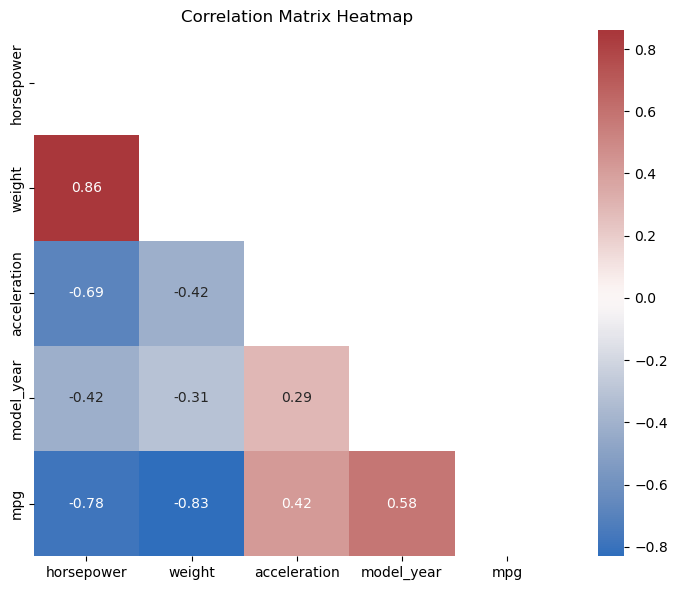

In [49]:
# Calculate the correlation matrix
correlation_matrix = model_df.corr().round(2)

# Mask the diagonal for a cleaner heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='vlag', center=0, square=True)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

### Discussion Question 1
Based on the heatmap, which variables have the strongest positive and negative correlations with $\text{mpg}$? What does a negative correlation between $\text{weight}$ and $\text{mpg}$ mean in practical terms?